# Koduppgift kapitel 3

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

## Uppgift 13

Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är dels att träna på att genomföra analyser dels att demonstrera hur mycket man kan göra även utan ML-modellering.

In [7]:
#note fick installera openpyxl för att kunna använda en excel fil
df = pd.read_excel('./dataset/hr_employee_data.xlsx') #ladda in data
df.info() #kolla datan

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.5 MB


datan verkar inte innehålla några saknade värde då det är 14999 datapunkter och alla kolumer har 14999 rader.

Vi har måste olika saker vi kan kolla på. Tanken är ju vad är förtaget intresserat av att veta?

- Time_spend_company: kan vara intressant att veta om våra anställda vill stanna hos eller om vi har snabb omsättning av anställda.
- Work_accident: olyckor kostar pengar. Detta kan vara intressant att kolla på eftersom det kan skadda arbetare, och vara olyckor som i material och tid kostar företaget pengar.
- Departments / number_of_projects har vi ett jämt fördelat arbete. finns det avdelningar som inte gör något eller någon som inte hinner med. detta kan kosta ett företag pengar.

Detta skulle jag säga är dom 3 mest intressanta punkterna att kolla på. 

### Överblick på våra 3 punkter

Vi kommer nu kolla på dom 3 punkterna som vi bestämde oss för.

vi kommer börja med Work_accidents sen number_of_projects, och till slut Time_spend_company

### Work place accidents

In [8]:
wa = df['Work_accident']

wa.head()


0    0
1    0
2    0
3    0
4    0
Name: Work_accident, dtype: int64

In [9]:
de = df['Department']

de.info()

<class 'pandas.Series'>
RangeIndex: 14999 entries, 0 to 14998
Series name: Department
Non-Null Count  Dtype
--------------  -----
14999 non-null  str  
dtypes: str(1)
memory usage: 215.2 KB


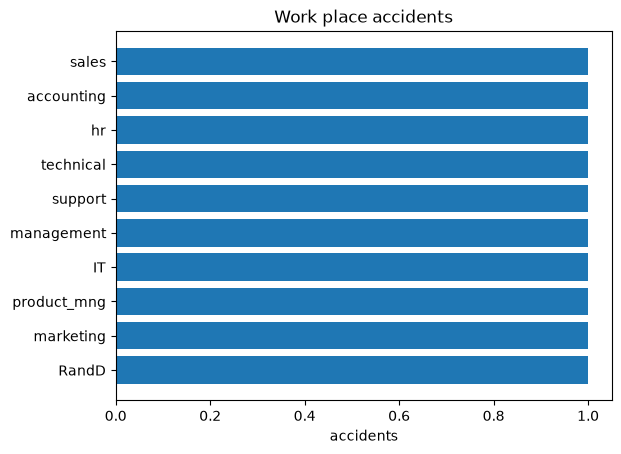

In [10]:
fig, ax = plt.subplots()

ax.barh(de, wa, align='center')
ax.yaxis.set_inverted(True)
ax.set_xlabel('accidents')
ax.set_title('Work place accidents')

plt.show()

In [11]:
pj = df['number_project']

pj.head()

0    2
1    5
2    7
3    5
4    2
Name: number_project, dtype: int64

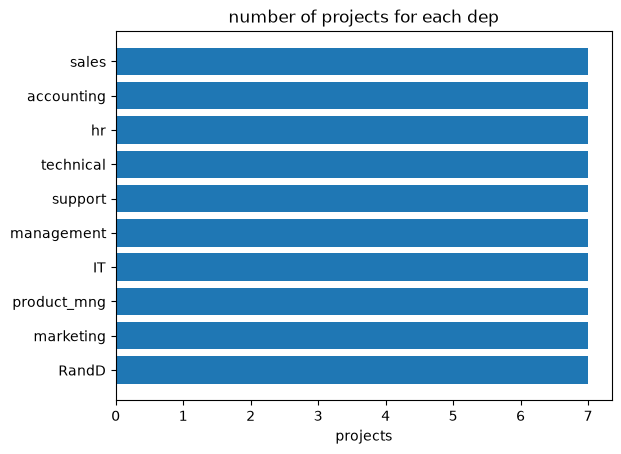

In [12]:
fig, ax = plt.subplots()

ax.barh(de, pj, align='center')
ax.yaxis.set_inverted(True)
ax.set_xlabel('projects')
ax.set_title('number of projects for each dep')

plt.show()

In [13]:
sl = df['satisfaction_level']

tsc = df['time_spend_company']

In [14]:
sl.head(5)

0    0.38
1    0.80
2    0.11
3    0.72
4    0.37
Name: satisfaction_level, dtype: float64

In [15]:
tsc.head(5)

0    3
1    6
2    4
3    5
4    3
Name: time_spend_company, dtype: int64

Text(0.5, 1.0, 'txt')

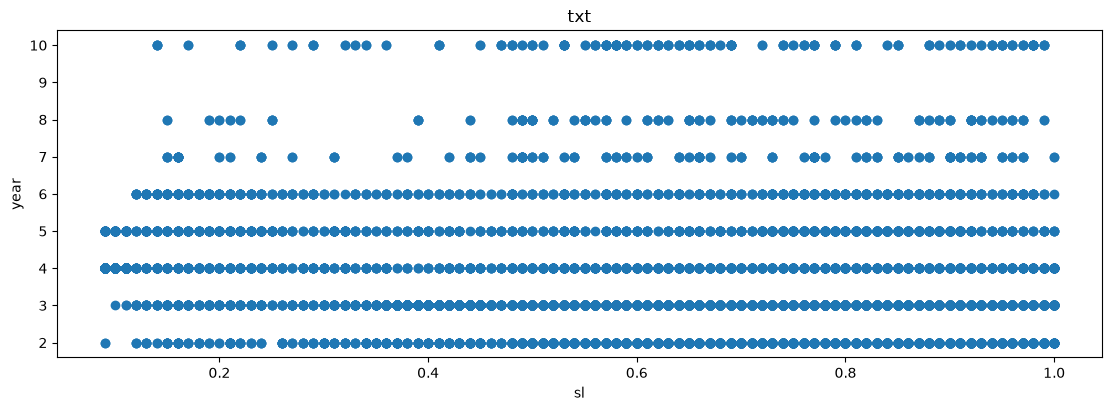

In [16]:
fig, axs = plt.subplots(1, figsize=(11, 4), layout='constrained')

axs.scatter(sl, tsc)
axs.set_xlabel('sl')
axs.set_ylabel('year')
axs.set_title('txt')

Efter allt detta kan jag egentligen utesluta att all den här datan är väldigt tråkig att kolla på.

jag förutsätter att jag nu måste kolla på saker som inte är relevanta för ett företag så som lön osv bara för att kunna göra uppgifterna i kap 4.

C:\Users\Mikae\AppData\Local\Temp\ipykernel_20164\406096581.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time_spend_company', y='satisfaction_level', data=df, palette='Set2')


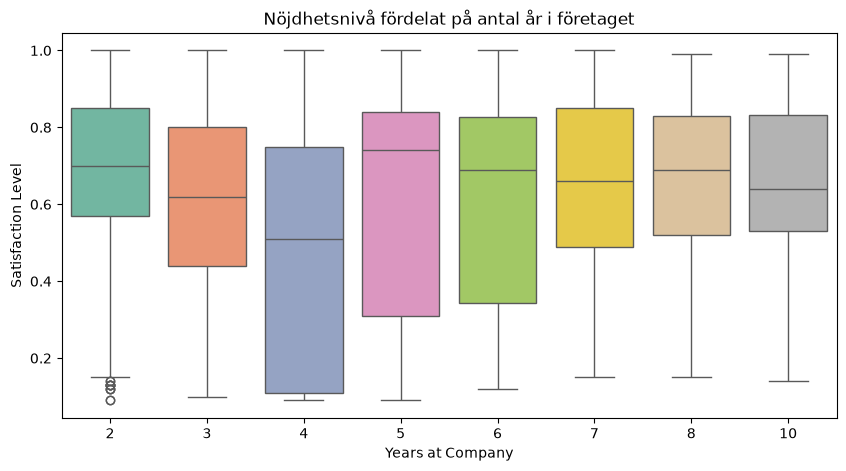

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='time_spend_company', y='satisfaction_level', data=df, palette='Set2')

plt.title('Nöjdhetsnivå fördelat på antal år i företaget')
plt.xlabel('Years at Company')
plt.ylabel('Satisfaction Level')
plt.show()

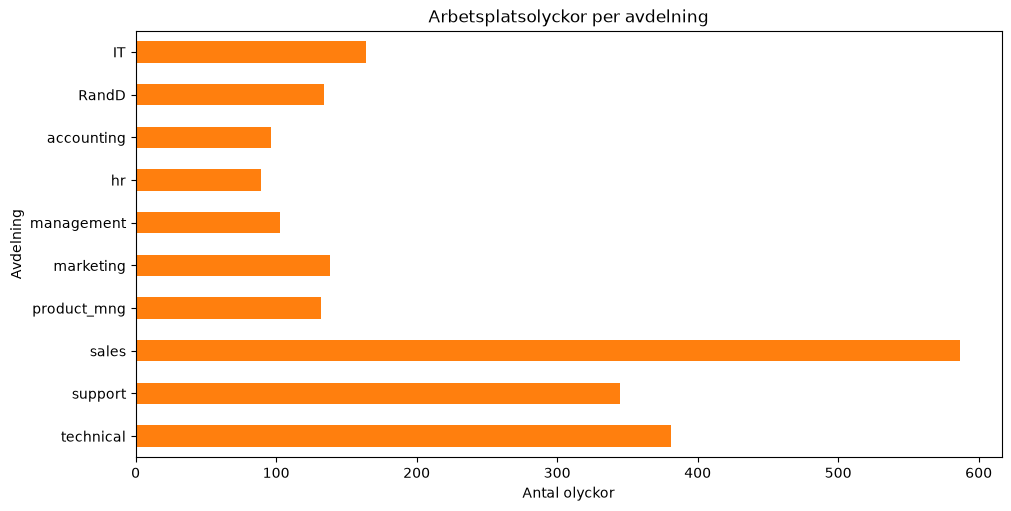

In [18]:
accidents_per_dept = df.groupby('Department')['Work_accident'].sum()

fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
accidents_per_dept.plot(kind='barh', ax=ax, color='tab:orange')

ax.set_xlabel('Antal olyckor')
ax.set_ylabel('Avdelning')
ax.set_title('Arbetsplatsolyckor per avdelning')
ax.invert_yaxis() # Sätter största högst upp

plt.show()

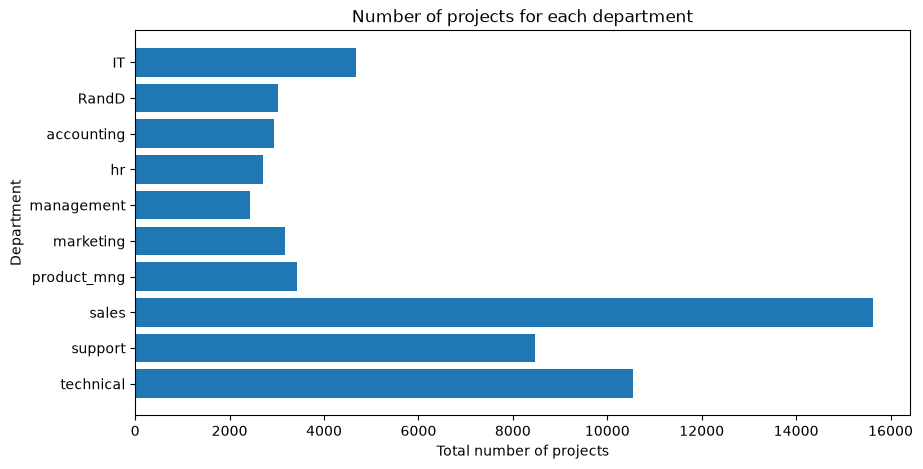

In [19]:
dept_projects = df.groupby('Department')['number_project'].sum()

# Plocka ut index (avdelningsnamn) och värden till listor/serier för axlarna
de = dept_projects.index
pj = dept_projects.values

# 2. Skapa figuren
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(de, pj, align='center')
ax.yaxis.set_inverted(True)
ax.set_xlabel('Total number of projects')
ax.set_ylabel('Department')
ax.set_title('Number of projects for each department')

plt.show()

Nu har jag lyckas få ut bra data. fick ta ett steg tillbaka och insåg att jag använde saker fel...

aja..

## Uppgift 14

In [4]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
X, y = load_diabetes(return_X_y=True, as_frame=True)

print(X.info())
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
<class 'pandas.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


In [21]:
X = X[['bmi', 'bp']]
y.name = 'disease_progression'

In [22]:
X_full, X_test, y_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

In [24]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_val)

print(root_mean_squared_error(y_val, lr_pred))

56.95086270947594


In [25]:
lr.fit(X_full, y_full)
lr_full_pred = lr.predict(X_test)

print(root_mean_squared_error(y_test, lr_full_pred))

61.15968459631288


## Uppgift 15

### A: skapa våran AI model

In [43]:
df = pd.read_csv('./dataset/car_price_dataset.csv', sep=';')

df.head(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [45]:
X = df.drop(['Price', 'Doors'], axis=1)

X.head(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Owner_Count
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,5
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,3
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,2
3,Audi,Q5,2023,2.0,Electric,Manual,160971,1
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3


In [46]:
y = df['Price']

y.head(5)

0     8501
1    12092
2    11171
3    11780
4     2867
Name: Price, dtype: int64

In [47]:
categorical_cols = ['Brand', 'Model', 'Fuel_Type', 'Transmission']
numerical_cols = ['Year', 'Engine_Size', 'Mileage', 'Owner_Count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


X_prepared = preprocessor.fit_transform(X)

print(X_prepared.shape)

(10000, 51)


In [48]:
X_full, X_test, y_full, y_test = train_test_split(X_prepared, y, train_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

In [49]:
rfr = RandomForestRegressor(random_state=42)

hyperparams = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [2, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rfr_gs = GridSearchCV(
    estimator=rfr,
    param_grid=hyperparams,
    scoring='neg_mean_squared_error')

rfr_gs.fit(X_train, y_train)

rfr_pred = rfr_gs.predict(X_val)

rmse_rfr = root_mean_squared_error(y_val, rfr_pred)

print('best params: ', rfr_gs.best_params_)
print('rmse test: ', rmse_rfr)

best params:  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
rmse test:  644.0349841369538


In [50]:
rfr_gs_2 =GridSearchCV(
    estimator=rfr,
    param_grid=hyperparams,
    scoring='neg_mean_squared_error')


rfr_gs_2.fit(X_full, y_full)

rfr_pred_2 = rfr_gs.predict(X_test)

rmse_rfr_2 = root_mean_squared_error(y_test, rfr_pred_2)

print('best params: ', rfr_gs_2.best_params_)
print('rmse test: ', rmse_rfr_2)

best params:  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
rmse test:  627.6217042596181


In [55]:
import joblib

joblib.dump(rfr_gs_2, 'car_model.pkl')
joblib.dump(preprocessor, 'car_preprocessor.pkl')

['car_preprocessor.pkl']

### B: streamlib app

appen hittar du [här](car_app.py)

### C:

hade ju kunnat vara bra till en bilfirmas hemsida om man vill ha en ca värdering om man funderar på att sälja sin bil eller tex en sida så som blocket.

även en bilhandlare hade kunnat använda det om dom stötter på en bil dom inte kan mycket om.

## Uppgift 16

**From kaggle:**

price price in US dollars (\$326--\$18,823)

carat weight of the diamond (0.2--5.01)

cut quality of the cut (Fair, Good, Very Good, Premium, Ideal)

color diamond colour, from J (worst) to D (best)

clarity a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

x length in mm (0--10.74)

y width in mm (0--58.9)

z depth in mm (0--31.8)

depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

table width of top of diamond relative to widest point (43--95)

In [57]:
df = pd.read_csv('./dataset/diamonds.csv')

df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [58]:
X = df.drop(['price', 'x', 'y', 'z'], axis=1)

y = df['price']


In [61]:
print('X info:')
print(X.info())
print('Y info:')
print(y.info())

X info:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 3.4 MB
None
Y info:
<class 'pandas.Series'>
RangeIndex: 53940 entries, 0 to 53939
Series name: price
Non-Null Count  Dtype
--------------  -----
53940 non-null  int64
dtypes: int64(1)
memory usage: 421.5 KB
None


In [62]:
cols = ['cut', 'color', 'clarity']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cols)
    ],
    remainder='passthrough'
)

X_pre = preprocessor.fit_transform(X)

In [64]:
X_full, X_test, y_full, y_test = train_test_split(X_pre, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

In [68]:
dtr = DecisionTreeRegressor(random_state=42)
lr = LinearRegression()

hyperparams = {
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

dtr_gs = GridSearchCV(
    estimator=dtr,
    param_grid=hyperparams,
    scoring='neg_mean_squared_error',
    cv=5)

dtr_gs.fit(X_train, y_train)

dtr_pred = dtr_gs.predict(X_val)

rmse_dtr = root_mean_squared_error(y_val, dtr_pred)

lr_fit = lr.fit(X_train, y_train)
lr_pred = lr_fit.predict(X_val)

rmse_lr = root_mean_squared_error(y_val, lr_pred)


print('best params: ', dtr_gs.best_params_)

print('rmse test dtr: ', rmse_dtr)
print('rmse test dtr: ', rmse_lr)

best params:  {'max_depth': None, 'min_samples_split': 2}
rmse test dtr:  32.324798475081636
rmse test dtr:  1129.6441467626973


In [72]:
dtr_gs.fit(X_full, y_full)

dtr_pred = dtr_gs.predict(X_test)

rmse_dtr = root_mean_squared_error(y_test, dtr_pred)

print('best params: ', dtr_gs.best_params_)

print('rmse test dtr: ', rmse_dtr)

best params:  {'max_depth': None, 'min_samples_split': 2}
rmse test dtr:  33.41142363794568
